# Movement Strategy Simulation

This notebook simulates each movement strategy with the same `MotorController` setup used in `backend.py`, then analyzes:
- each motor command over time
- reconstructed tactor position from resulting motor outputs (not requested path)
- wire consistency issues (too tight / inconsistent trilateration residual)

Default pattern (fully configurable):
1. Start at `(0, 0)`
2. Move right from center to `50%` of half-width
3. One clockwise circle
4. Return to `(0, 0)`


In [1]:
import math
from dataclasses import dataclass
from pathlib import Path
import sys
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

# FIXED ROOT DETECTION: works from repo root, analysis folders, validation folders,
# or this movement_strategy subfolder. If Jupyter still shows the older
# one-parent check, you are running a stale browser/server copy of the notebook.
CURRENT_DIR = Path.cwd().resolve()
THIS_NOTEBOOK_DIR = Path(r'C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\validetion\movement_strategy')
SEARCH_STARTS = [CURRENT_DIR, THIS_NOTEBOOK_DIR]
REPO_ROOT = next(
    (path for start in SEARCH_STARTS for path in (start, *start.parents) if (path / 'motor_controller.py').exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        f'Could not locate the repository root. Checked upward from {SEARCH_STARTS}. '
        'Set REPO_ROOT manually to the folder containing motor_controller.py.'
    )

repo_root_str = str(REPO_ROOT)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

print(f'FIXED ROOT DETECTION: using REPO_ROOT={REPO_ROOT}')

from consts import EDGE_THRESHOLD, TOP_HEIGHT, TOP_WIDTH
from haptic_mapping import map_object_displacement_to_tactor
from motor_controller import HandOrientation, MotorController, MotorSetId, MovementStrategy

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


FIXED ROOT DETECTION: using REPO_ROOT=C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics


In [2]:
@dataclass
class SimulationConfig:
    # MotorController setup (mirrors backend usage)
    top_width: float = TOP_WIDTH
    top_height: float = TOP_HEIGHT
    edge_threshold: float = EDGE_THRESHOLD
    motor_spacing: float = 1000.0
    move_factor: float = 1.0
    diagonal_threshold: float = 0.5
    hand_orientation: HandOrientation = HandOrientation.NOT_MIRRORED
    stiffness_value_normalized = 1

    # Pattern controls
    outward_fraction_of_half_width: float = 0.5
    # line_steps: int = 40
    # circle_steps: int = 220
    # return_steps: int = 40
    line_steps: int = 40
    circle_steps: int = 220
    return_steps: int = 40

    oppose_object_motion: bool = True
    # Analysis controls.
    # The 2-D trilateration residual flags cable/geometry inconsistencies. All four
    # strategies now share the SAME isosceles mechanism triangle (default_model) for
    # both encode and decode, so the commanded path reconstructs round.
    # The 2-D strategies (cardinal, cardinal_diagonal, free_form) sit at residual
    # ~0.16-0.6. The IK strategy carries an expected extra ~1.4 baseline residual
    # (max ~3.2) because IK wire lengths are 3-D while this diagnostic reconstructs
    # in 2-D. Therefore the default threshold is set just above the IK baseline.
    # Lower this back to 1.25 only if you intentionally want to visualize the IK
    # 3-D working-height residual as a warning.
    wire_residual_alert_threshold: float = 3.3

    # Live display controls
    live_plots: bool = False
    live_update_interval: int = 8


config = SimulationConfig()
config


SimulationConfig(top_width=640, top_height=480, edge_threshold=30, motor_spacing=1000.0, move_factor=1.0, diagonal_threshold=0.5, hand_orientation=<HandOrientation.NOT_MIRRORED: 'not_mirrored'>, outward_fraction_of_half_width=0.5, line_steps=40, circle_steps=220, return_steps=40, oppose_object_motion=True, wire_residual_alert_threshold=3.3, live_plots=False, live_update_interval=8)

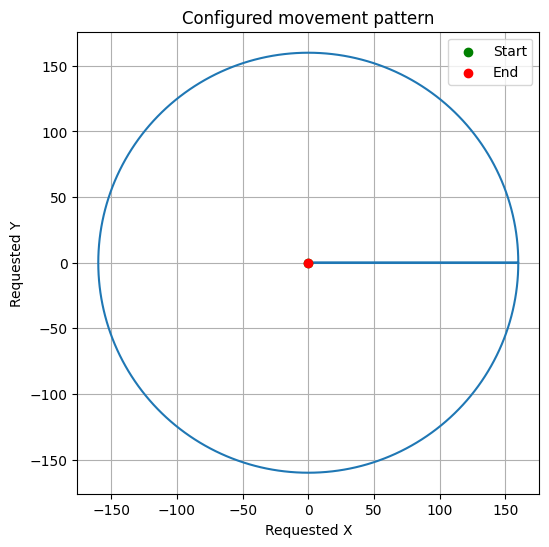

,step,segment,x,y
0,0,outward_right,0.0,0.0
1,1,outward_right,4.0,0.0
2,2,outward_right,8.0,0.0
3,3,outward_right,12.0,0.0
4,4,outward_right,16.0,0.0


In [3]:
DEFAULT_PATTERN_TEMPLATE: list[dict[str, Any]] = [
    {
        'type': 'line',
        'name': 'outward_right',
        'start': (0.0, 0.0),
        'end': '$OUTWARD_POINT',
        'steps': 'line_steps',
    },
    {
        'type': 'circle',
        'name': 'clockwise_circle',
        'center': (0.0, 0.0),
        'radius': '$OUTWARD_RADIUS',
        'start_angle_deg': 0.0,
        'sweep_angle_deg': -360.0,
        'steps': 'circle_steps',
    },
    {
        'type': 'line',
        'name': 'back_to_center',
        'start': '$OUTWARD_POINT',
        'end': (0.0, 0.0),
        'steps': 'return_steps',
    },
]


def _resolve_value(value: Any, context: dict[str, Any], cfg: SimulationConfig) -> Any:
    if isinstance(value, str):
        if value.startswith('$'):
            return context[value]
        if hasattr(cfg, value):
            return getattr(cfg, value)
    return value


def build_pattern_points(
    cfg: SimulationConfig,
    pattern_template: list[dict[str, Any]] | None = None,
) -> pd.DataFrame:
    template = pattern_template or DEFAULT_PATTERN_TEMPLATE

    half_width = cfg.top_width / 2.0
    outward_x = half_width * cfg.outward_fraction_of_half_width
    context = {
        '$OUTWARD_POINT': (outward_x, 0.0),
        '$OUTWARD_RADIUS': outward_x,
    }

    rows: list[dict[str, float | str]] = []
    include_start = True

    for segment in template:
        segment_type = str(segment['type'])
        segment_name = str(segment.get('name', segment_type))
        steps = int(_resolve_value(segment['steps'], context, cfg))
        if steps < 1:
            raise ValueError(f'Invalid steps for {segment_name}: {steps}')

        if segment_type == 'line':
            start = np.array(_resolve_value(segment['start'], context, cfg), dtype=float)
            end = np.array(_resolve_value(segment['end'], context, cfg), dtype=float)

            t_values = np.linspace(0.0, 1.0, num=steps + 1)
            if not include_start:
                t_values = t_values[1:]

            for t in t_values:
                point = start + t * (end - start)
                rows.append({'segment': segment_name, 'x': float(point[0]), 'y': float(point[1])})

        elif segment_type == 'circle':
            center = np.array(_resolve_value(segment['center'], context, cfg), dtype=float)
            radius = float(_resolve_value(segment['radius'], context, cfg))
            start_angle = math.radians(float(_resolve_value(segment.get('start_angle_deg', 0.0), context, cfg)))
            sweep_angle = math.radians(float(_resolve_value(segment.get('sweep_angle_deg', -360.0), context, cfg)))

            angles = np.linspace(start_angle, start_angle + sweep_angle, num=steps + 1)
            if not include_start:
                angles = angles[1:]

            for angle in angles:
                x = center[0] + radius * math.cos(angle)
                y = center[1] + radius * math.sin(angle)
                rows.append({'segment': segment_name, 'x': float(x), 'y': float(y)})

        else:
            raise ValueError(f'Unsupported segment type: {segment_type}')

        include_start = False

    path_df = pd.DataFrame(rows)
    path_df.insert(0, 'step', np.arange(len(path_df), dtype=int))
    return path_df


pattern_df = build_pattern_points(config)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pattern_df['x'], pattern_df['y'], linewidth=1.5)
ax.scatter(pattern_df.iloc[0]['x'], pattern_df.iloc[0]['y'], color='green', label='Start', zorder=3)
ax.scatter(pattern_df.iloc[-1]['x'], pattern_df.iloc[-1]['y'], color='red', label='End', zorder=3)
ax.set_title('Configured movement pattern')
ax.set_xlabel('Requested X')
ax.set_ylabel('Requested Y')
ax.set_aspect('equal', 'box')
ax.legend()
plt.show()

pattern_df.head()


In [4]:
from kinematics import unified_ik_starter as ik_module
from kinematics import wire_forward_kinematics as wire_fk_module


def get_motor_anchors(motor_spacing: float) -> np.ndarray:
    """Reconstruction anchors matching the *real* mechanism triangle.

    The physical mechanism solved by ``unified_ik_starter`` is the isosceles
    triangle defined in ``default_model()`` (base 24.2, height 25.9 - NOT
    equilateral). Motor commands are wire-length deltas measured against that
    triangle and scaled by ``motor_spacing / base_span``. To reconstruct the
    tactor consistently for *every* strategy, the decode must use the SAME
    triangle scaled by the SAME factor.

    Motor order matches the IK leg order: 0=top, 1=bottom-right, 2=bottom-left.
    """
    anchors = ik_module.default_model()["anchors"]
    base_span = math.hypot(
        anchors["right"][0] - anchors["left"][0],
        anchors["right"][1] - anchors["left"][1],
    )
    scale = motor_spacing / base_span
    return np.array(
        [anchors[leg][:2] for leg in ("top", "right", "left")],
        dtype=float,
    ) * scale


def reconstruct_tactor_xy(
    final_lengths: np.ndarray,
    anchors: np.ndarray,
) -> tuple[float, float, float, np.ndarray, np.ndarray]:
    # Linearized trilateration from three anchor distances
    p1 = anchors[0]
    r1 = final_lengths[0]

    A = []
    b = []
    for i in (1, 2):
        xi, yi = anchors[i]
        ri = final_lengths[i]
        A.append([2.0 * (xi - p1[0]), 2.0 * (yi - p1[1])])
        b.append(
            (r1 ** 2 - ri ** 2)
            - (p1[0] ** 2 - xi ** 2)
            - (p1[1] ** 2 - yi ** 2)
        )

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    solution, *_ = np.linalg.lstsq(A, b, rcond=None)
    x = float(solution[0])
    y = float(solution[1])

    predicted_lengths = np.linalg.norm(anchors - np.array([x, y]), axis=1)
    length_error = predicted_lengths - final_lengths
    residual_rmse = float(np.sqrt(np.mean(length_error ** 2)))

    return x, y, residual_rmse, predicted_lengths, length_error

In [5]:
def show_live_state(partial_df: pd.DataFrame, strategy_name: str, alert_threshold: float) -> None:
    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    idx0 = int(partial_df['motor_index_0'].iloc[0])
    idx1 = int(partial_df['motor_index_1'].iloc[0])
    idx2 = int(partial_df['motor_index_2'].iloc[0])

    axes[0].plot(partial_df['step'], partial_df['motor_0'], label=f'Motor {idx0}')
    axes[0].plot(partial_df['step'], partial_df['motor_1'], label=f'Motor {idx1}')
    axes[0].plot(partial_df['step'], partial_df['motor_2'], label=f'Motor {idx2}')
    axes[0].set_title(f'{strategy_name}: motor commands')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Motor position command')
    axes[0].legend()

    axes[1].plot(
        partial_df['object_x'],
        partial_df['object_y'],
        '--',
        label='Virtual object path',
        alpha=0.8,
        zorder=1,
    )
    axes[1].plot(
        partial_df['tactor_x'],
        partial_df['tactor_y'],
        label='Reconstructed tactor',
        linewidth=2,
        zorder=2,
    )

    issues = partial_df[partial_df['wire_issue']]
    if not issues.empty:
        axes[1].scatter(
            issues['tactor_x'],
            issues['tactor_y'],
            c='red',
            s=42,
            marker='o',
            edgecolors='black',
            linewidths=0.8,
            label='Wire issue',
            zorder=10,
        )

    axes[1].set_title(f'{strategy_name}: virtual object vs reconstructed tactor')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_aspect('equal', 'box')
    axes[1].legend(loc='upper right')

    fig.suptitle(f'Live update | issue threshold={alert_threshold:.2f}', y=1.03)
    plt.tight_layout()
    display(fig)
    plt.close(fig)


def simulate_strategy(
    strategy: MovementStrategy,
    pattern: pd.DataFrame,
    cfg: SimulationConfig,
) -> pd.DataFrame:
    controller = MotorController(
        movement_strategy=strategy,
        top_width=cfg.top_width,
        top_height=cfg.top_height,
        edge_threshold=cfg.edge_threshold,
        motor_spacing=cfg.motor_spacing,
        move_factor=cfg.move_factor,
        diagonal_threshold=cfg.diagonal_threshold,
        hand_orientation=cfg.hand_orientation,
    )

    motor_indices = [0, 1, 2]
    current_motor_positions = {idx: 0 for idx in motor_indices}

    anchors = get_motor_anchors(controller._motor_spacing)
    initial_lengths = np.linalg.norm(anchors - np.array([0.0, 0.0]), axis=1)
    ik_model = ik_module.default_model()
    sim_to_ik_scale = controller._get_ik_base_span(ik_model) / controller._motor_spacing
    ik_to_sim_scale = 1.0 / sim_to_ik_scale
    ik_rest_p1 = wire_fk_module.rest_pose(ik_model)
    ik_previous_p1 = ik_rest_p1.copy()

    rows: list[dict[str, Any]] = []

    final_step = int(pattern['step'].iat[-1])
    update_every = max(1, cfg.live_update_interval)

    for _, point in pattern.iterrows():
        step = int(point['step'])
        object_x = float(point['x'])
        object_y = float(point['y'])
        segment = str(point['segment'])

        target_x, target_y = map_object_displacement_to_tactor(
            obj_x=object_x,
            obj_y=object_y,
            oppose_motion=cfg.oppose_object_motion,
        )

        movements = controller.calculate_motor_movements(
            motor_set_id=MotorSetId.MOTORS_0_2,
            stiffness_value=cfg.stiffness_value_normalized,
            obj_x=target_x,
            obj_y=target_y,
            motors_enabled=True,
            reset_to_origin=False,
        )

        for movement in movements:
            if movement.index in current_motor_positions:
                current_motor_positions[movement.index] = movement.pos

        motor_offsets = np.array([current_motor_positions[idx] for idx in motor_indices], dtype=float)
        final_lengths = initial_lengths + motor_offsets

        if strategy == MovementStrategy.IK:
            fk_result = wire_fk_module.solve_wire_fk(
                motor_offsets * sim_to_ik_scale,
                ik_model,
                initial_P1=ik_previous_p1,
                rest_P1=ik_rest_p1,
            )
            ik_previous_p1 = fk_result.P1
            tactor_x = float(fk_result.P1[0] * ik_to_sim_scale)
            tactor_y = float(fk_result.P1[1] * ik_to_sim_scale)
            residual_rmse = float(fk_result.residual_rms * ik_to_sim_scale)
            length_error = np.full(3, residual_rmse, dtype=float)
            wire_too_tight = False
            dominant_wire_idx = int(np.argmax(np.abs(fk_result.residuals)))
            dominant_wire_motor_index = motor_indices[dominant_wire_idx]
            dominant_wire_error = float(abs(fk_result.residuals[dominant_wire_idx]) * ik_to_sim_scale)
        else:
            wire_too_tight = bool(np.any(final_lengths <= 0.0))
            if wire_too_tight:
                tactor_x = float('nan')
                tactor_y = float('nan')
                residual_rmse = float('inf')
                length_error = np.array([float('nan'), float('nan'), float('nan')], dtype=float)
                dominant_wire_motor_index = -1
                dominant_wire_error = float('nan')
            else:
                tactor_x, tactor_y, residual_rmse, _, length_error = reconstruct_tactor_xy(final_lengths, anchors)
                dominant_wire_idx = int(np.argmax(np.abs(length_error)))
                dominant_wire_motor_index = motor_indices[dominant_wire_idx]
                dominant_wire_error = float(abs(length_error[dominant_wire_idx]))

        tactor_error = float('nan')
        if not math.isnan(tactor_x) and not math.isnan(tactor_y):
            tactor_error = float(math.hypot(tactor_x - target_x, tactor_y - target_y))

        wire_issue = wire_too_tight or (residual_rmse > cfg.wire_residual_alert_threshold)

        rows.append(
            {
                'strategy': strategy.value,
                'step': step,
                'segment': segment,
                'object_x': object_x,
                'object_y': object_y,
                'target_x': target_x,
                'target_y': target_y,
                'motor_index_0': motor_indices[0],
                'motor_index_1': motor_indices[1],
                'motor_index_2': motor_indices[2],
                'motor_0': float(motor_offsets[0]),
                'motor_1': float(motor_offsets[1]),
                'motor_2': float(motor_offsets[2]),
                'wire_length_0': float(final_lengths[0]),
                'wire_length_1': float(final_lengths[1]),
                'wire_length_2': float(final_lengths[2]),
                'tactor_x': tactor_x,
                'tactor_y': tactor_y,
                'tactor_error': tactor_error,
                'wire_residual_rmse': float(residual_rmse),
                'wire_too_tight': wire_too_tight,
                'wire_issue': wire_issue,
                'dominant_wire_motor_index': dominant_wire_motor_index,
                'dominant_wire_error': dominant_wire_error,
            }
        )

        if cfg.live_plots and (step % update_every == 0 or step == final_step):
            show_live_state(pd.DataFrame(rows), strategy.value, cfg.wire_residual_alert_threshold)

    return pd.DataFrame(rows)


In [6]:
strategies = [
    MovementStrategy.CARDINAL,
    MovementStrategy.CARDINAL_DIAGONAL,
    MovementStrategy.FREE_FORM,
    MovementStrategy.IK,
]

pattern_df = build_pattern_points(config)
results = [simulate_strategy(strategy, pattern_df, config) for strategy in strategies]
all_results = pd.concat(results, ignore_index=True)

print(f'Path points: {len(pattern_df)}')
print(f'Strategies: {len(strategies)}')
print(f'Total rows: {len(all_results)}')
all_results.head()


Path points: 301
Strategies: 4
Total rows: 1204


,strategy,step,segment,object_x,object_y,target_x,target_y,motor_index_0,motor_index_1,motor_index_2,...,wire_length_1,wire_length_2,tactor_x,tactor_y,tactor_error,wire_residual_rmse,wire_too_tight,wire_issue,dominant_wire_motor_index,dominant_wire_error
0,cardinal,0,outward_right,0.0,0.0,-0.0,-0.0,0,1,2,...,671.852539,671.852539,0.000000,1.359677e-14,1.359677e-14,0.000000,False,False,0,0.000000
1,cardinal,1,outward_right,4.0,0.0,-4.0,-0.0,0,1,2,...,669.852539,673.852539,2.687410,1.868726e-03,6.687410e+00,0.003747,False,False,0,0.003942
2,cardinal,2,outward_right,8.0,0.0,-8.0,-0.0,0,1,2,...,666.852539,676.852539,6.718525,1.167954e-02,1.471853e+01,0.023421,False,False,0,0.024635
3,cardinal,3,outward_right,12.0,0.0,-12.0,-0.0,0,1,2,...,663.852539,679.852539,10.749641,2.989961e-02,2.274966e+01,0.059962,False,False,0,0.063064
4,cardinal,4,outward_right,16.0,0.0,-16.0,-0.0,0,1,2,...,660.852539,682.852539,14.780756,5.652896e-02,3.078081e+01,0.113376,False,False,0,0.119227


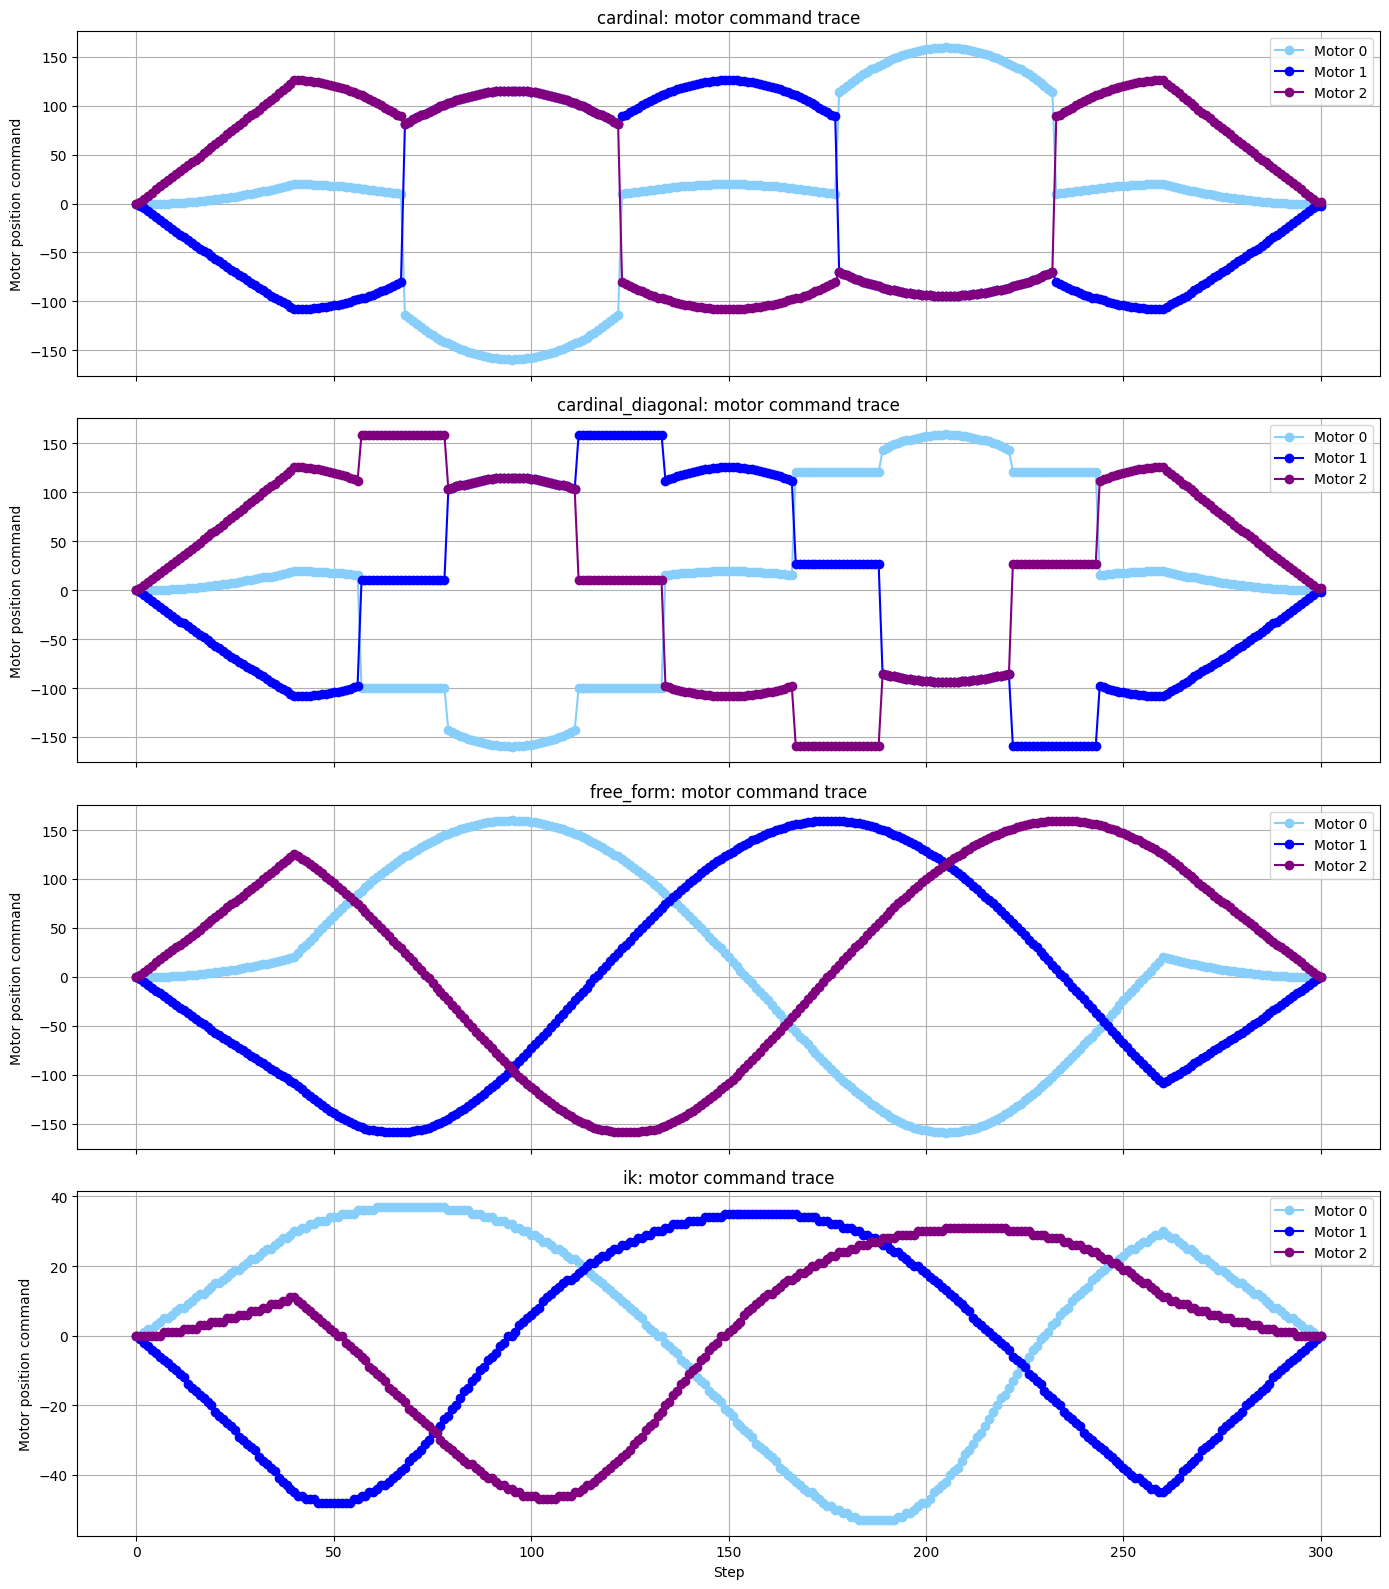

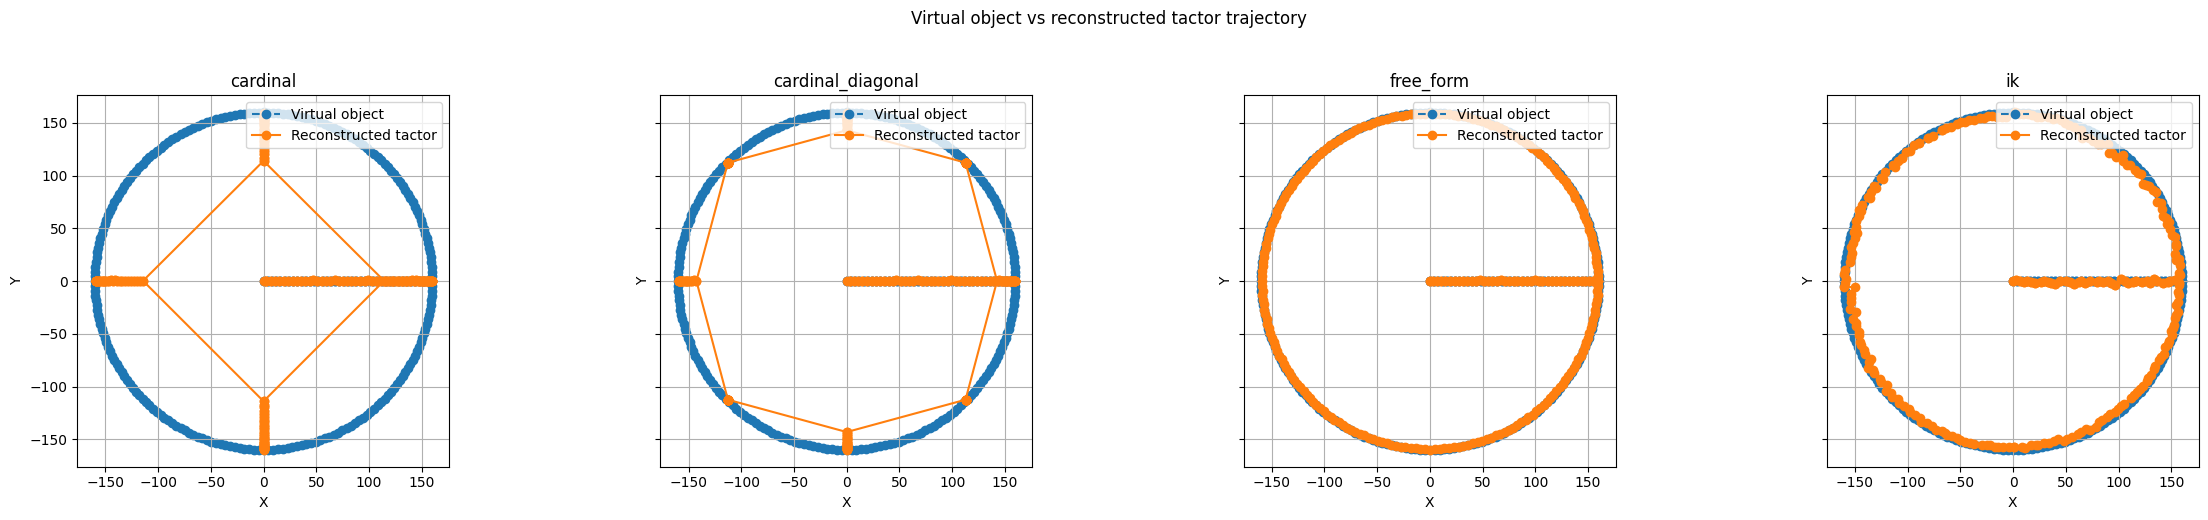

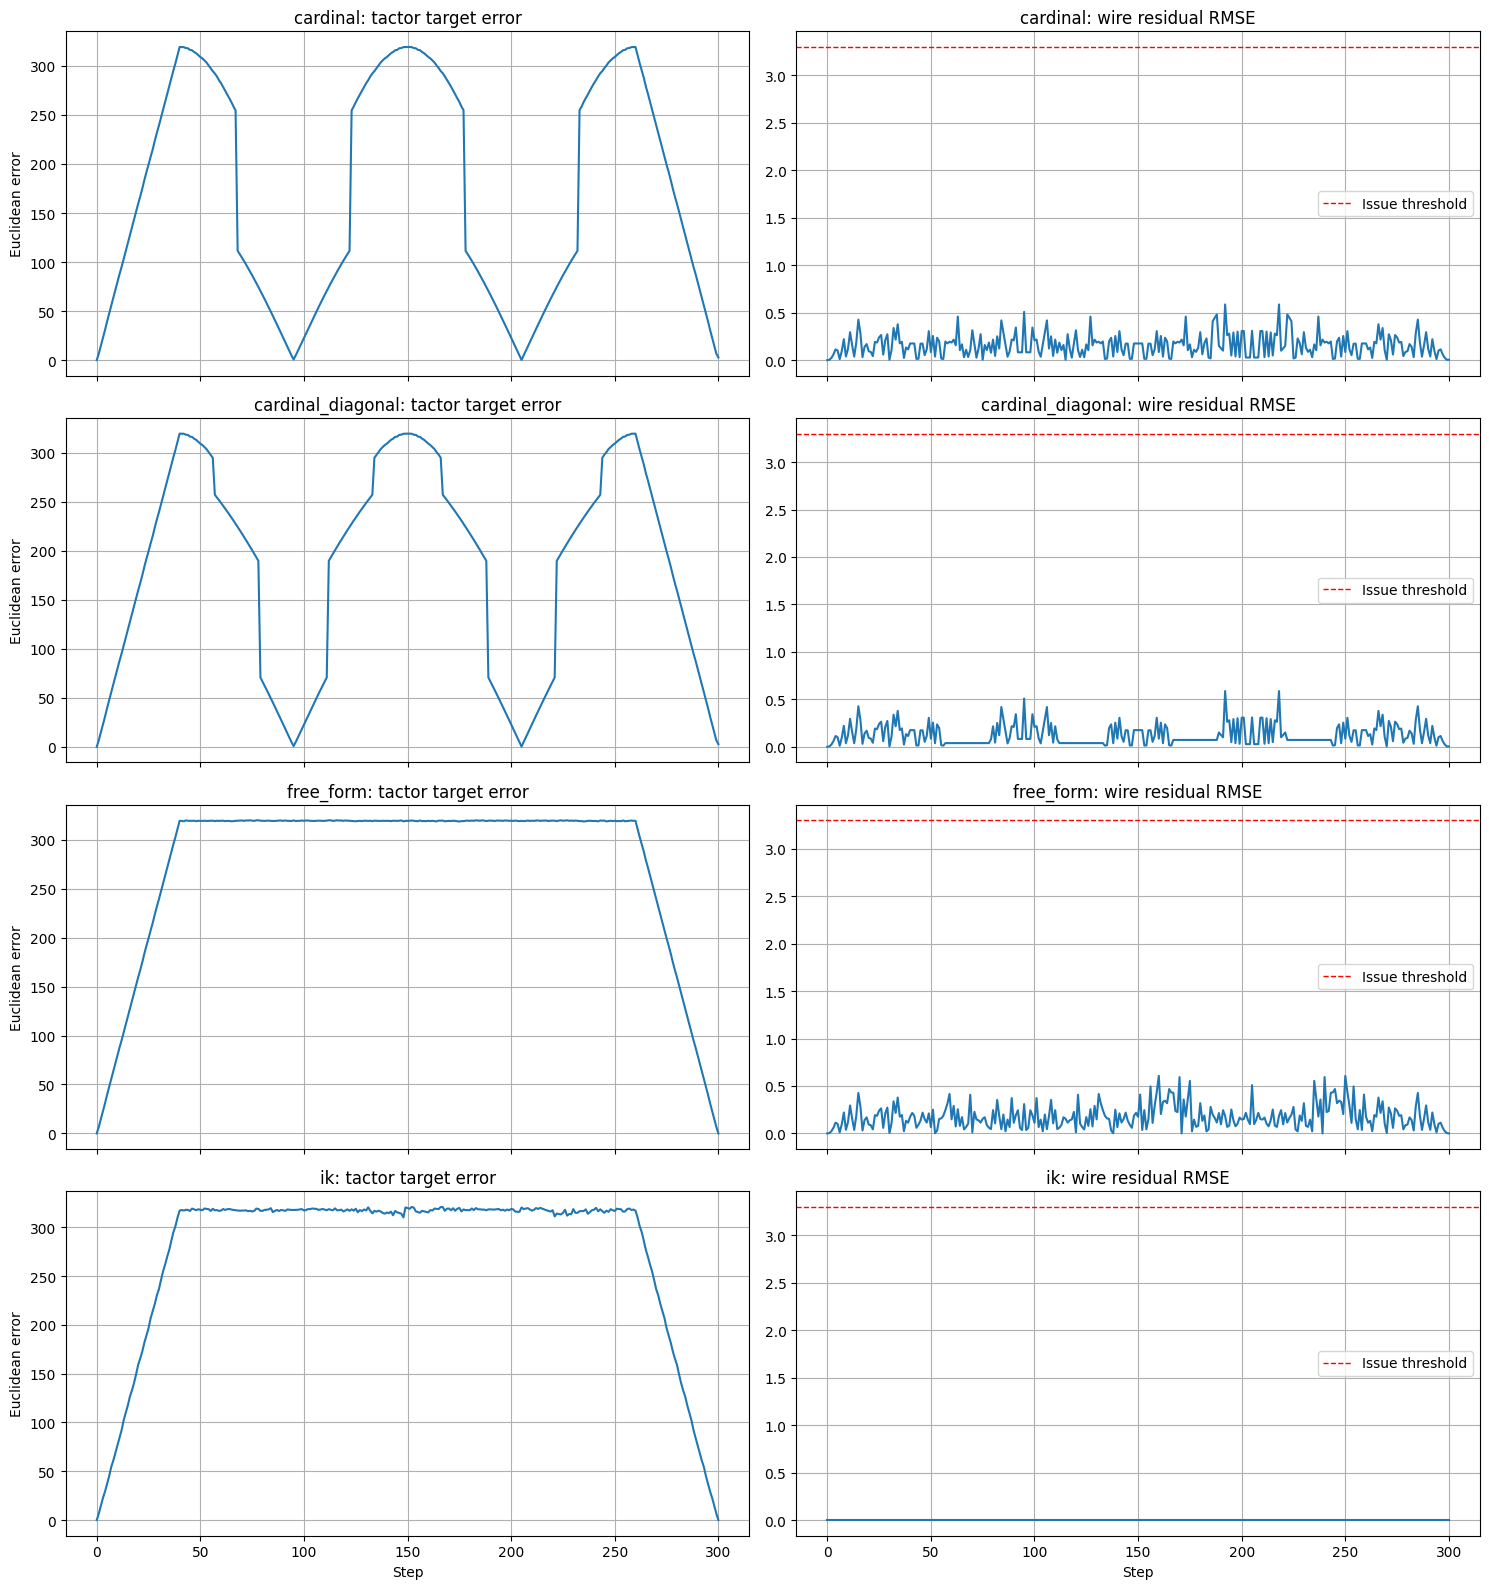

Strategy summary:


,mean_tactor_error,max_tactor_error,mean_wire_residual,max_wire_residual,issue_steps,issue_ratio
strategy,,,,,,
cardinal,172.348537,319.319619,1.599615e-01,5.869257e-01,0,0.0
cardinal_diagonal,184.310497,319.319619,1.240015e-01,5.869257e-01,0,0.0
free_form,275.720203,319.839824,1.788420e-01,6.064166e-01,0,0.0
ik,273.837576,320.781550,2.906009e-09,4.131761e-08,0,0.0


No wire consistency issues detected at the configured threshold.


In [7]:
def evenly_sample_steps(part: pd.DataFrame, sample_count: int) -> pd.DataFrame:
    if sample_count < 2:
        raise ValueError('sample_count must be at least 2.')

    if part.empty:
        return part

    sampled_len = min(sample_count, len(part))
    sampled_indices = np.linspace(0, len(part) - 1, num=sampled_len, dtype=int)
    sampled_indices = np.unique(sampled_indices)
    return part.iloc[sampled_indices]

def plot_motor_movements(df: pd.DataFrame, sample_count: int | None) -> None:
    strategy_names = [s.value for s in strategies]
    motor_colors = {
        0: 'lightskyblue',
        1: 'blue',
        2: 'purple',
    }
    fig, axes = plt.subplots(len(strategy_names), 1, figsize=(14, 4 * len(strategy_names)), sharex=True)
    if len(strategy_names) == 1:
        axes = [axes]

    for i, strategy_name in enumerate(strategy_names):
        ax = axes[i]
        part = df[df['strategy'] == strategy_name].reset_index(drop=True)
        if sample_count:
            part = evenly_sample_steps(part, sample_count)
        idx0 = int(part['motor_index_0'].iloc[0])
        idx1 = int(part['motor_index_1'].iloc[0])
        idx2 = int(part['motor_index_2'].iloc[0])

        ax.plot(part['step'], part['motor_0'], '-o', label=f'Motor {idx0}', color=motor_colors[0])
        ax.plot(part['step'], part['motor_1'], '-o', label=f'Motor {idx1}', color=motor_colors[1])
        ax.plot(part['step'], part['motor_2'], '-o', label=f'Motor {idx2}', color=motor_colors[2])
        ax.set_title(f'{strategy_name}: motor command trace' + (f' ({len(part)} samples)' if sample_count else ''))
        ax.set_ylabel('Motor position command')
        ax.legend()

    axes[-1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()

def plot_tactor_paths(df: pd.DataFrame, sample_count: int | None) -> None:
    strategy_names = [s.value for s in strategies]
    fig, axes = plt.subplots(1, len(strategy_names), figsize=(6 * len(strategy_names), 5), sharex=True, sharey=True)
    if len(strategy_names) == 1:
        axes = [axes]

    for i, strategy_name in enumerate(strategy_names):
        ax = axes[i]
        part = df[df['strategy'] == strategy_name].reset_index(drop=True)
        if sample_count:
            part = evenly_sample_steps(part, sample_count)

        ax.plot(
            part['object_x'],
            part['object_y'],
            '--o',
            label='Virtual object',
            zorder=1,
        )
        ax.plot(
            part['tactor_x'],
            part['tactor_y'],
            '-o',
            label='Reconstructed tactor',
            zorder=2,
        )

        issues = part[part['wire_issue']]
        if not issues.empty:
            ax.scatter(
                issues['tactor_x'],
                issues['tactor_y'],
                c='red',
                s=42,
                marker='o',
                edgecolors='black',
                linewidths=0.8,
                label='Wire issue',
                zorder=10,
            )

        ax.set_title(f'{strategy_name}' + (f' ({len(part)} samples)' if sample_count else ''))
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_aspect('equal', 'box')
        ax.legend(loc='upper right')

    plt.suptitle('Virtual object vs reconstructed tactor trajectory', y=1.03)
    plt.tight_layout()
    plt.show()


def plot_error_metrics(df: pd.DataFrame, alert_threshold: float) -> None:
    strategy_names = [s.value for s in strategies]
    fig, axes = plt.subplots(len(strategy_names), 2, figsize=(15, 4 * len(strategy_names)), sharex=True)
    if len(strategy_names) == 1:
        axes = np.array([axes])

    for i, strategy_name in enumerate(strategy_names):
        part = df[df['strategy'] == strategy_name]

        axes[i, 0].plot(part['step'], part['tactor_error'])
        axes[i, 0].set_title(f'{strategy_name}: tactor target error')
        axes[i, 0].set_ylabel('Euclidean error')

        axes[i, 1].plot(part['step'], part['wire_residual_rmse'])
        axes[i, 1].axhline(alert_threshold, color='red', linestyle='--', linewidth=1, label='Issue threshold')
        axes[i, 1].set_title(f'{strategy_name}: wire residual RMSE')
        axes[i, 1].legend()

    axes[-1, 0].set_xlabel('Step')
    axes[-1, 1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()


plot_motor_movements(all_results, sample_count=0)
plot_tactor_paths(all_results, sample_count=0)
plot_error_metrics(all_results, config.wire_residual_alert_threshold)

summary_source = all_results.replace([np.inf, -np.inf], np.nan)
summary = (
    summary_source.groupby('strategy')
    .agg(
        mean_tactor_error=('tactor_error', 'mean'),
        max_tactor_error=('tactor_error', 'max'),
        mean_wire_residual=('wire_residual_rmse', 'mean'),
        max_wire_residual=('wire_residual_rmse', 'max'),
        issue_steps=('wire_issue', 'sum'),
        issue_ratio=('wire_issue', 'mean'),
    )
    .sort_index()
)

print('Strategy summary:')
display(summary)

issues = all_results[all_results['wire_issue']].copy()
if issues.empty:
    print('No wire consistency issues detected at the configured threshold.')
else:
    print(f'Wire issues detected in {len(issues)} steps.')
    issue_cols = [
        'strategy',
        'step',
        'segment',
        'target_x',
        'target_y',
        'tactor_x',
        'tactor_y',
        'wire_too_tight',
        'wire_residual_rmse',
        'dominant_wire_motor_index',
        'dominant_wire_error',
    ]
    display(issues[issue_cols].head(100))


## IK MovementStrategy comparison

The IK path now uses the in-repository `MovementStrategy.IK` implementation from `backend.py` end-to-end: target pose → mechanism IK for all three legs → solved `P3` branches and angles → Bowden-cable displacement `ΔLi`.

For IK reconstruction, the notebook uses the matching mechanism wire FK. For cardinal-diagonal reconstruction, it keeps planar trilateration because that strategy commands direct anchor-length changes.

In [8]:
def summarize_strategy_results(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in strategies:
        part = df[df['strategy'] == strategy.value]
        rows.append(
            {
                'strategy': strategy.value,
                'rows': len(part),
                'wire_issue_count': int(part['wire_issue'].sum()),
                'max_tactor_error': float(part['tactor_error'].max(skipna=True)),
                'max_wire_residual_rmse': float(part['wire_residual_rmse'].replace(np.inf, np.nan).max(skipna=True)),
                'motor_0_min': float(part['motor_0'].min(skipna=True)),
                'motor_0_max': float(part['motor_0'].max(skipna=True)),
                'motor_1_min': float(part['motor_1'].min(skipna=True)),
                'motor_1_max': float(part['motor_1'].max(skipna=True)),
                'motor_2_min': float(part['motor_2'].min(skipna=True)),
                'motor_2_max': float(part['motor_2'].max(skipna=True)),
            }
        )
    return pd.DataFrame(rows)


ik_results = all_results[all_results['strategy'] == MovementStrategy.IK.value].reset_index(drop=True)
if ik_results.empty:
    raise RuntimeError('MovementStrategy.IK was not included in strategies or produced no rows.')

ik_controller = MotorController(
    movement_strategy=MovementStrategy.IK,
    top_width=config.top_width,
    top_height=config.top_height,
    edge_threshold=config.edge_threshold,
    motor_spacing=config.motor_spacing,
    move_factor=config.move_factor,
    diagonal_threshold=config.diagonal_threshold,
    hand_orientation=config.hand_orientation,
)
ik_solver_path = Path(ik_controller._get_ik_module().__file__).resolve()

print('IK strategy is simulated through MotorController(MovementStrategy.IK).')
print(f'IK solver path: {ik_solver_path.relative_to(REPO_ROOT)}')
print(
    'Backend-equivalent inputs: oppose_object_motion=' 
    f'{config.oppose_object_motion}, stiffness={config.stiffness_value_normalized}, '
    f'move_factor={config.move_factor}, motor_spacing={config.motor_spacing}.'
)

display(summarize_strategy_results(all_results))
print('IK sample rows:')
display(
    ik_results[
        [
            'step', 'segment', 'object_x', 'object_y', 'target_x', 'target_y',
            'motor_index_0', 'motor_0', 'motor_index_1', 'motor_1', 'motor_index_2', 'motor_2',
            'wire_issue', 'tactor_error', 'wire_residual_rmse',
        ]
    ].head(10)
)


IK strategy is simulated through MotorController(MovementStrategy.IK).
IK solver path: kinematics\unified_ik_starter.py
Backend-equivalent inputs: oppose_object_motion=True, stiffness=1, move_factor=1.0, motor_spacing=1000.0.


,strategy,rows,wire_issue_count,max_tactor_error,max_wire_residual_rmse,motor_0_min,motor_0_max,motor_1_min,motor_1_max,motor_2_min,motor_2_max
0,cardinal,301,0,319.319619,5.869257e-01,-160.0,160.0,-108.0,126.0,-108.0,126.0
1,cardinal_diagonal,301,0,319.319619,5.869257e-01,-160.0,160.0,-159.0,159.0,-159.0,159.0
2,free_form,301,0,319.839824,6.064166e-01,-160.0,160.0,-159.0,159.0,-159.0,159.0
3,ik,301,0,320.781550,4.131761e-08,-53.0,37.0,-48.0,35.0,-47.0,31.0


IK sample rows:


,step,segment,object_x,object_y,target_x,target_y,motor_index_0,motor_0,motor_index_1,motor_1,motor_index_2,motor_2,wire_issue,tactor_error,wire_residual_rmse
0,0,outward_right,0.0,0.0,-0.0,-0.0,0,0.0,1,0.0,2,0.0,False,0.000000,0.000000e+00
1,1,outward_right,4.0,0.0,-4.0,-0.0,0,0.0,1,-1.0,2,0.0,False,6.760398,4.131761e-08
2,2,outward_right,8.0,0.0,-8.0,-0.0,0,1.0,1,-2.0,2,0.0,False,14.683698,9.186449e-13
3,3,outward_right,12.0,0.0,-12.0,-0.0,0,2.0,1,-3.0,2,0.0,False,22.646030,8.022769e-13
4,4,outward_right,16.0,0.0,-16.0,-0.0,0,2.0,1,-4.0,2,0.0,False,29.261616,3.284072e-08
5,5,outward_right,20.0,0.0,-20.0,-0.0,0,3.0,1,-5.0,2,0.0,False,37.157991,6.765067e-13
6,6,outward_right,24.0,0.0,-24.0,-0.0,0,4.0,1,-6.0,2,0.0,False,45.037306,5.736895e-13
7,7,outward_right,28.0,0.0,-28.0,-0.0,0,5.0,1,-7.0,2,1.0,False,54.400764,1.157045e-12
8,8,outward_right,32.0,0.0,-32.0,-0.0,0,5.0,1,-8.0,2,1.0,False,60.952760,2.540055e-08
9,9,outward_right,36.0,0.0,-36.0,-0.0,0,6.0,1,-9.0,2,1.0,False,68.698912,4.179682e-13


In [ ]:
# Publication-style text for the combined comparison figure.
TITLE_FS = 48
LABEL_FS = 45
TICK_FS = 45
LEGEND_FS = 45
LINE_W = 2.8
GRID_ALPHA = 0.28
PAPER_COMPARISON_FIGSIZE = (42, 14)


# Higher-is-better composite score for comparing movement strategies.
# Circularity is kept important, but command efficiency/smoothness gets most
# of the weight because the goal is a near-circular path with short, smooth
# motor-command traces. Wire/tightness flags are intentionally excluded.
SCORE_WEIGHTS = {
    'aspect_error': 0.20,
    'circle_fit_rmse': 0.20,
    'peak_abs_command': 0.15,
    'rms_command': 0.15,
    'total_motor_travel': 0.20,
    'max_step_jump': 0.10,
}
SCORE_DISPLAY_COLUMNS = [
    'score',
    'aspect_Y/X',
    'aspect_error',
    'circle_fit_rmse',
    'peak_abs_command',
    'rms_command',
    'total_motor_travel',
    'max_step_jump',
]


def _style_panel(ax):
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.title.set_fontsize(TITLE_FS)
    ax.xaxis.label.set_size(LABEL_FS)
    ax.yaxis.label.set_size(LABEL_FS)
    ax.grid(True, alpha=GRID_ALPHA)


def _fit_circle_rmse(circle: pd.DataFrame) -> float:
    """Radial RMSE around the best-fit circle; lower means more circular."""
    points = circle.dropna(subset=['tactor_x', 'tactor_y'])
    if len(points) < 3:
        return float('nan')

    x = points['tactor_x'].to_numpy(dtype=float)
    y = points['tactor_y'].to_numpy(dtype=float)
    # x^2 + y^2 = 2*a*x + 2*b*y + c, where (a, b) is the fitted center.
    A = np.column_stack([2.0 * x, 2.0 * y, np.ones_like(x)])
    b = x**2 + y**2
    a_fit, b_fit, c_fit = np.linalg.lstsq(A, b, rcond=None)[0]
    radius = math.sqrt(max(c_fit + a_fit**2 + b_fit**2, 0.0))
    radial_error = np.sqrt((x - a_fit) ** 2 + (y - b_fit) ** 2) - radius
    return float(np.sqrt(np.mean(radial_error**2)))


def _circle_metrics(part: pd.DataFrame) -> dict[str, float | int]:
    circle = part.loc[part['segment'].eq('clockwise_circle')].dropna(subset=['tactor_x', 'tactor_y'])
    xspan = float(circle['tactor_x'].max() - circle['tactor_x'].min())
    yspan = float(circle['tactor_y'].max() - circle['tactor_y'].min())
    ratio = float(yspan / xspan) if xspan else float('nan')

    motor_columns = [f'motor_{idx}' for idx in range(3)]
    motor_commands = part[motor_columns].to_numpy(dtype=float)
    motor_steps = np.diff(motor_commands, axis=0)

    return {
        'rows': int(len(part)),
        'circle_samples': int(len(circle)),
        'circle_Xspan': xspan,
        'circle_Yspan': yspan,
        'aspect_Y/X': ratio,
        'aspect_error': float(abs(ratio - 1.0)),
        'circle_fit_rmse': _fit_circle_rmse(circle),
        'peak_abs_command': float(np.nanmax(np.abs(motor_commands))),
        'rms_command': float(np.sqrt(np.nanmean(motor_commands**2))),
        'total_motor_travel': float(np.nansum(np.abs(motor_steps))),
        'max_step_jump': float(np.nanmax(np.abs(motor_steps))),
    }

def _add_strategy_scores(metrics: pd.DataFrame) -> pd.DataFrame:
    scored = metrics.copy()
    weighted_components = []
    for column, weight in SCORE_WEIGHTS.items():
        values = scored[column].replace([np.inf, -np.inf], np.nan)
        finite_values = values.dropna()
        if finite_values.empty:
            component = pd.Series(0.0, index=scored.index)
        else:
            best = float(finite_values.min())
            worst = float(finite_values.max())
            if math.isclose(best, worst):
                component = pd.Series(1.0, index=scored.index)
            else:
                # All score columns are lower-is-better. Best strategy gets 1, worst gets 0.
                component = 1.0 - ((values - best) / (worst - best))
                component = component.fillna(0.0).clip(lower=0.0, upper=1.0)
        weighted_components.append(component * weight)

    scored['score'] = 100.0 * sum(weighted_components)
    return scored.sort_values('score', ascending=False)


def make_movement_strategy_score_comparison(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in strategies:
        part = df[df['strategy'].eq(strategy.value)].reset_index(drop=True)
        if part.empty:
            continue
        row = {'method': strategy.value}
        row.update(_circle_metrics(part))
        rows.append(row)
    if not rows:
        raise RuntimeError('No strategy rows found. Re-run the simulation cell first.')
    return _add_strategy_scores(pd.DataFrame(rows).set_index('method'))


def make_cardinal_diagonal_vs_ik_comparison(df: pd.DataFrame) -> pd.DataFrame:
    score_data = make_movement_strategy_score_comparison(df)
    required = [MovementStrategy.CARDINAL_DIAGONAL.value, MovementStrategy.IK.value]
    missing = [strategy for strategy in required if strategy not in score_data.index]
    if missing:
        raise RuntimeError(f'Missing rows for: {missing}. Re-run the simulation cell first.')
    return score_data.loc[required]


score_data = make_movement_strategy_score_comparison(all_results)
comparison_data = make_cardinal_diagonal_vs_ik_comparison(all_results)
print('Movement-strategy score data (higher score is better):')
display(score_data[SCORE_DISPLAY_COLUMNS].round(3))
print('CD vs IK comparison data:')
display(comparison_data[SCORE_DISPLAY_COLUMNS].round(3))

def plot_cardinal_diagonal_vs_ik_circle_and_motor_commands(
    df: pd.DataFrame,
    sample_count: int | None = None,
) -> None:
    cd = df[df['strategy'].eq(MovementStrategy.CARDINAL_DIAGONAL.value)].reset_index(drop=True)
    ik_part = df[df['strategy'].eq(MovementStrategy.IK.value)].reset_index(drop=True)
    if cd.empty or ik_part.empty:
        raise RuntimeError('Cardinal-diagonal and IK rows are both required.')
    if sample_count:
        cd = evenly_sample_steps(cd, sample_count).reset_index(drop=True)
        ik_part = evenly_sample_steps(ik_part, sample_count).reset_index(drop=True)

    circle_cd = cd['segment'].eq('clockwise_circle')
    circle_ik = ik_part['segment'].eq('clockwise_circle')
    plot_scores = make_movement_strategy_score_comparison(df)
    cd_metrics = plot_scores.loc[MovementStrategy.CARDINAL_DIAGONAL.value]
    ik_metrics = plot_scores.loc[MovementStrategy.IK.value]

    ik_colors = {
        0: '#ff6b35',  # red-orange
        1: '#d7191c',  # red
        2: '#9c0519',  # maroon
    }
    cd_colors = {
        0: '#f6c85f',  # gold
        1: '#ff9f1c',  # orange
        2: '#cc5500',  # dark orange
    }

    fig, (ax_circle, ax_motor) = plt.subplots(
        1,
        2,
        figsize=PAPER_COMPARISON_FIGSIZE,
        gridspec_kw={'width_ratios': [0.90, 1.20], 'wspace': 0.18},
        constrained_layout=False,
    )

    commanded_handle, = ax_circle.plot(
        ik_part.loc[circle_ik, 'target_x'],
        ik_part.loc[circle_ik, 'target_y'],
        '--',
        color='0.45',
        linewidth=LINE_W,
        label='Commanded',
        zorder=1,
    )
    ik_handle, = ax_circle.plot(
        ik_part.loc[circle_ik, 'tactor_x'],
        ik_part.loc[circle_ik, 'tactor_y'],
        '-',
        color='firebrick',
        linewidth=LINE_W + 0.6,
        alpha=0.82,
        label="IK",
        zorder=2,
    )
    cd_handle, = ax_circle.plot(
        cd.loc[circle_cd, 'tactor_x'],
        cd.loc[circle_cd, 'tactor_y'],
        '-',
        color='darkorange',
        linewidth=LINE_W + 0.2,
        label="CD",
        zorder=3,
    )
    ax_circle.set_title('Circular reconstruction')
    ax_circle.set_xlabel('X')
    ax_circle.set_ylabel('Y')
    ax_circle.set_yticks(np.arange(-150, 151, 50))
    ax_circle.set_aspect('equal', 'box')
    ax_circle.set_anchor('E')
    _style_panel(ax_circle)
    ax_circle.legend(
        [commanded_handle, ik_handle, cd_handle],
        [h.get_label() for h in (commanded_handle, ik_handle, cd_handle)],
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        fontsize=LEGEND_FS,
        frameon=False,
        handlelength=1.25,
        columnspacing=0.55,
    )

    ax_motor.axhline(0.0, color='0.25', linewidth=1.6, alpha=0.6)

    # Plot IK first, then cardinal-diagonal on top.
    for motor_idx in range(3):
        motor_label = int(ik_part[f'motor_index_{motor_idx}'].iloc[0])
        ax_motor.plot(
            ik_part['step'],
            ik_part[f'motor_{motor_idx}'],
            '-',
            color=ik_colors[motor_idx],
            linewidth=LINE_W + 0.2,
            alpha=0.82,
            label=f'IK M{motor_label}',
            zorder=2,
        )
    for motor_idx in range(3):
        motor_label = int(cd[f'motor_index_{motor_idx}'].iloc[0])
        ax_motor.plot(
            cd['step'],
            cd[f'motor_{motor_idx}'],
            '--',
            color=cd_colors[motor_idx],
            linewidth=LINE_W + 0.2,
            label=f'CD M{motor_label}',
            zorder=3,
        )

    ax_motor.set_title('Motor commands')
    ax_motor.set_xlabel('Step')
    ax_motor.set_ylabel('Command', labelpad=4)
    ax_motor.set_yticks(np.arange(-150, 151, 50))
    _style_panel(ax_motor)
    ax_motor.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=6,
        fontsize=LEGEND_FS,
        frameon=False,
        handlelength=1.25,
        columnspacing=0.55,
    )

    fig.align_labels()
    fig.subplots_adjust(left=0.055, right=0.99, bottom=0.25, top=0.86, wspace=0.18)

    local_fig_dir = THIS_NOTEBOOK_DIR / 'figures'
    local_fig_dir.mkdir(parents=True, exist_ok=True)
    fig_path = local_fig_dir / 'cardinal_diagonal_vs_ik_circle_and_motor_commands.png'
    fig_path_tmp = local_fig_dir / 'cardinal_diagonal_vs_ik_circle_and_motor_commands.tmp.png'
    fig.savefig(fig_path_tmp, dpi=150)
    fig_path_tmp.replace(fig_path)
    print(f'Saved combined circle/motor-command comparison to: {fig_path}')
    plt.show()


plot_cardinal_diagonal_vs_ik_circle_and_motor_commands(all_results, sample_count=0)
